# Task 5 

Using smarties.png again since the objects have clear round boundaries.

Blurring with a 5x5 Gaussian first, otherwise small noise in the image gets detected as
fake edges.

Three threshold pairs: 50/100, 50/150 and 50/250. I kept the low one fixed at 50 on
purpose so I can see exactly what raising the high threshold does (the task asks for this).

**How the two thresholds work (hysteresis)**
- Above the high threshold = definitely an edge, keep it
- Below the low threshold = noise, throw it away
- In between = only keep it if it's connected to a strong edge

That last rule is why Canny gives continuous outlines instead of broken dots.

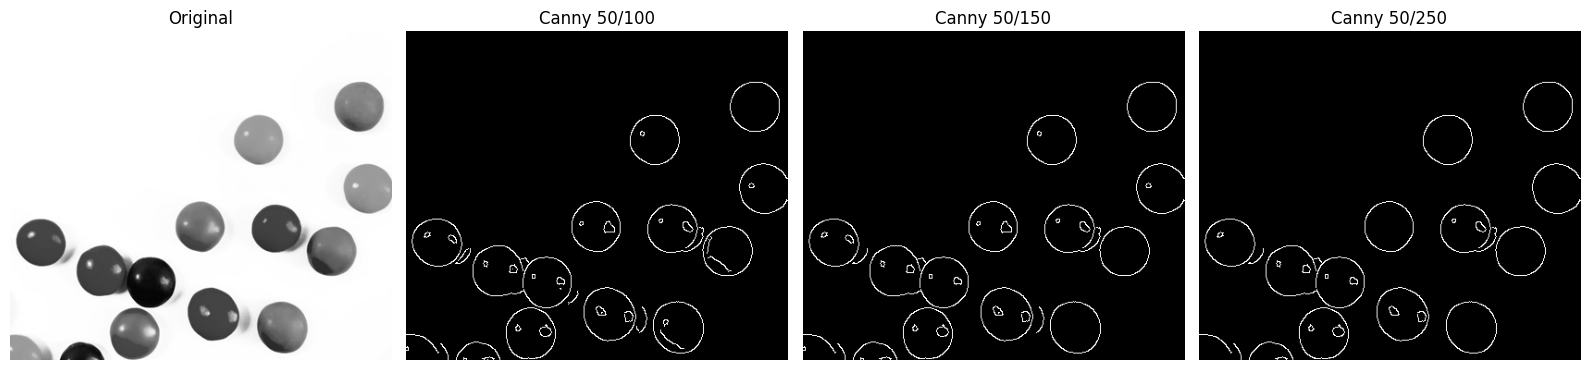

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("smarties.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: smarties.png not found")
else:
    # Blur first so noise does not turn into fake edges
    blur = cv2.GaussianBlur(img, (5, 5), 0)

    # Three threshold pairs, low stays fixed so we can see what high does
    e1 = cv2.Canny(blur, 50, 100)
    e2 = cv2.Canny(blur, 50, 150)
    e3 = cv2.Canny(blur, 50, 250)

    titles = ["Original", "Canny 50/100", "Canny 50/150", "Canny 50/250"]
    images = [img, e1, e2, e3]

    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### What I found

**Strong edges** :  the outlines of the smarties. These show up at every setting because
the jump from coloured object to white background is big.

**Weak edges** : the shadows under the objects and the boundary of the dark purple one.
These are visible at 50/100 but start disappearing as the high threshold goes up.

**Missing edges** : at 50/250 the dark smartie's outline breaks up. Its contrast against
its own shadow isn't strong enough to pass the higher threshold.

**Unwanted edges** : at 50/100 there are some stray marks from faint reflections on the
white background. That's noise getting counted as edges.

**How changing the thresholds changes the result**

Raising the high threshold makes Canny stricter about what counts as a definite edge, so
fewer weak edges get rescued by hysteresis. The output gets cleaner but you start losing
real boundaries. Lowering it picks up everything including noise.

The blur matters too becuase without it there's way more speckled junk in the output.

Best result for me was 50/150. It keeps the object outlines without picking up the
background noise.